In [358]:
import pandas as pd
import numpy as np
import seaborn as sns


# LOADING CSV FILE

In [359]:
df = pd.read_csv("Housing.csv")

In [360]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [361]:
#Checking for number of roles and columns in the dataset

print(df.shape[0])  #Rows
print(df.shape[1])  #Columns

545
13


In [362]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [363]:
#Target column
y = ["price"]

#features columns
X = [["area", "bedrooms", "bathrooms", "stories", "mainroad", "guestroom", "basement", 
     "hotwaterheating", "airconditioning", "parking", "prefarea", "furnishingstatus"]]

In [364]:
#Checking for missing values in each column
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

#### There's no column with missing values and therefore there's no need to handle missing values

In [365]:
#Checking for duplicate rows
df.duplicated().sum()

0

#### There are no duplicate rows

In [366]:
# Converting categorical columns into numeric form
df = pd.get_dummies(df, drop_first=True)

# FEATURE ENGINEERING


In [367]:
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [368]:
df.drop(columns=['mainroad_yes'], inplace=True)

In [369]:
df['bed_per_story'] = df['bedrooms'] / df['stories']

In [370]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,bed_per_story
0,13300000,7420,4,2,3,2,False,False,False,True,True,False,False,1.333333
1,12250000,8960,4,4,4,3,False,False,False,True,False,False,False,1.000000
2,12250000,9960,3,2,2,2,False,True,False,False,True,True,False,1.500000
3,12215000,7500,4,2,2,3,False,True,False,True,True,False,False,2.000000
4,11410000,7420,4,1,2,2,True,True,False,True,False,False,False,2.000000


# TRAIN AND TEST SPLIT

In [371]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [372]:
X = df.drop('price', axis=1)
y = df['price']

In [373]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# LINEAR REGESSION MODEL

In [374]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [375]:
y_pred = model.predict(X_test)

In [376]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 981712.5721577101
RMSE: 1342818.2550968537
R² Score: 0.6432612906072512


 # RANDOM FOREST REGRESSOR

In [377]:
from sklearn.ensemble import RandomForestRegressor

In [378]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [379]:
rf_pred = rf_model.predict(X_test)

In [380]:
print("Random Forest:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² Score:", r2_score(y_test, rf_pred))

Random Forest:
MAE: 1028203.5948012234
RMSE: 1392846.8400739501
R² Score: 0.6161845171107914


In [381]:
print(f"{'Metric':<10} {'Linear Reg':>12} {'Random Forest':>14}")
print(f"{'MAE':<10} {mean_absolute_error(y_test, y_pred):>12.2f} {mean_absolute_error(y_test, rf_pred):>14.2f}")
print(f"{'RMSE':<10} {np.sqrt(mean_squared_error(y_test, y_pred)):>12.2f} {np.sqrt(mean_squared_error(y_test, rf_pred)):>14.2f}")
print(f"{'R²':<10} {r2_score(y_test, y_pred):>12.4f} {r2_score(y_test, rf_pred):>14.4f}")

Metric       Linear Reg  Random Forest
MAE           981712.57     1028203.59
RMSE         1342818.26     1392846.84
R²               0.6433         0.6162


<Axes: xlabel='price', ylabel='Count'>

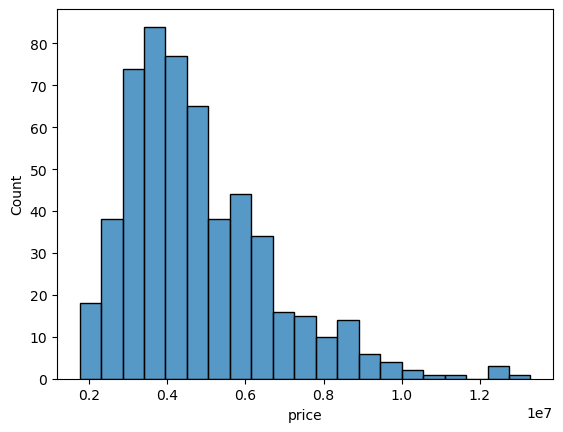

In [382]:
#Histogram showing the distribution of house prices
sns.histplot(df, x = "price")

<function matplotlib.pyplot.show(close=None, block=None)>

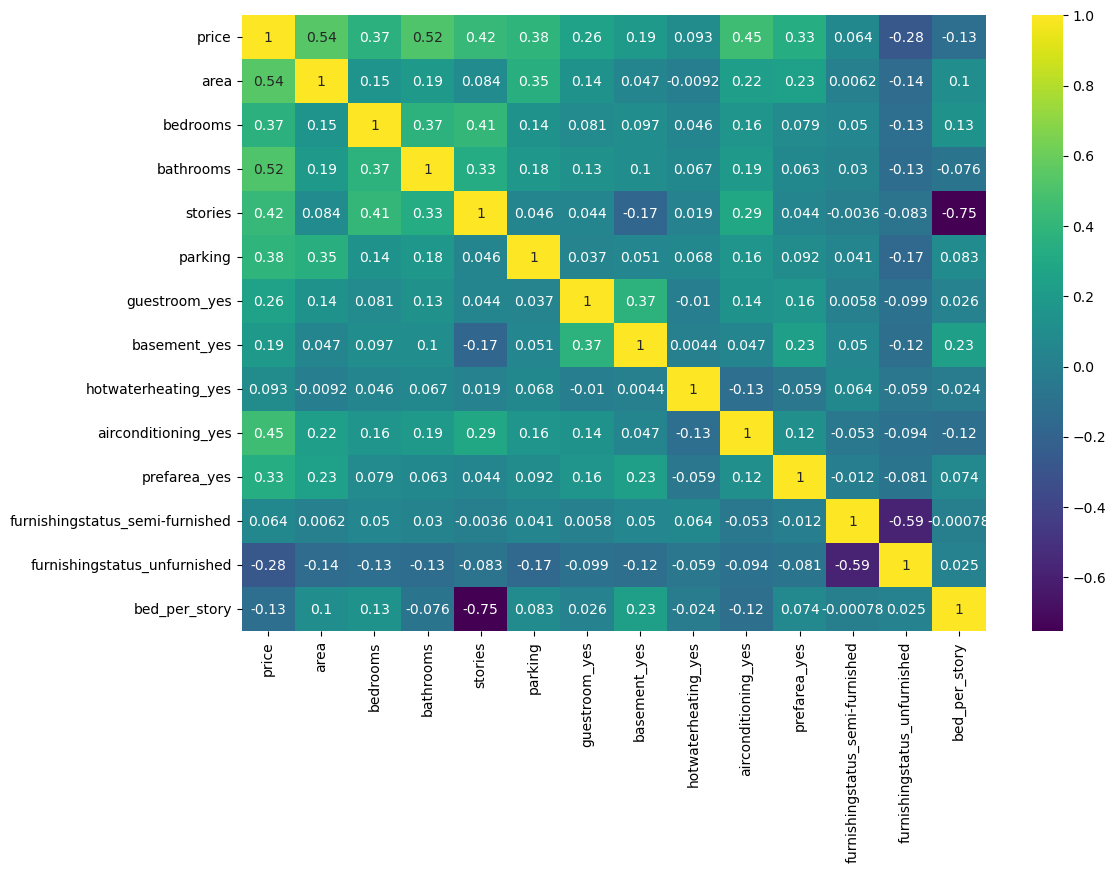

In [383]:
#Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap= "viridis", annot = True)
plt.show

<Axes: xlabel='area', ylabel='price'>

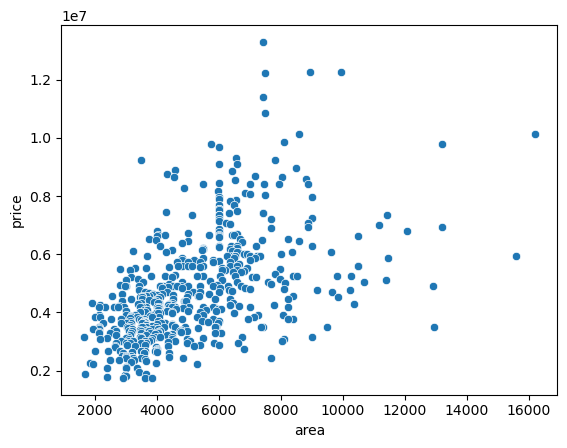

In [384]:
#A chart of my choice because customers first consider the size or space of a house
sns.scatterplot(x='area', y='price', data=df)

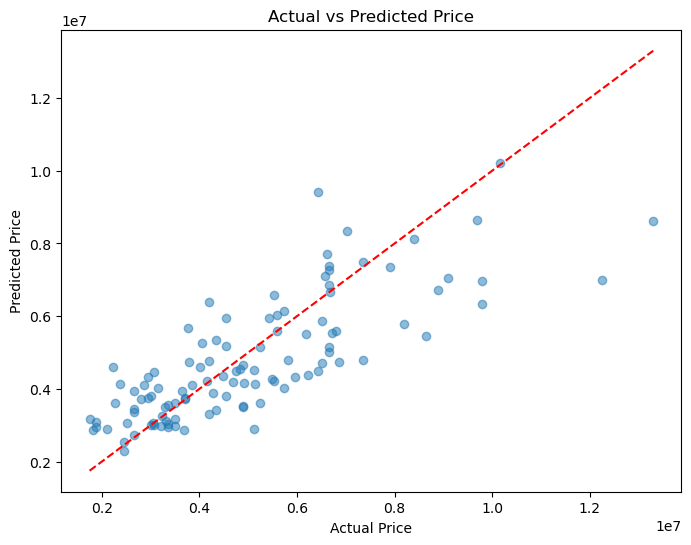

In [385]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

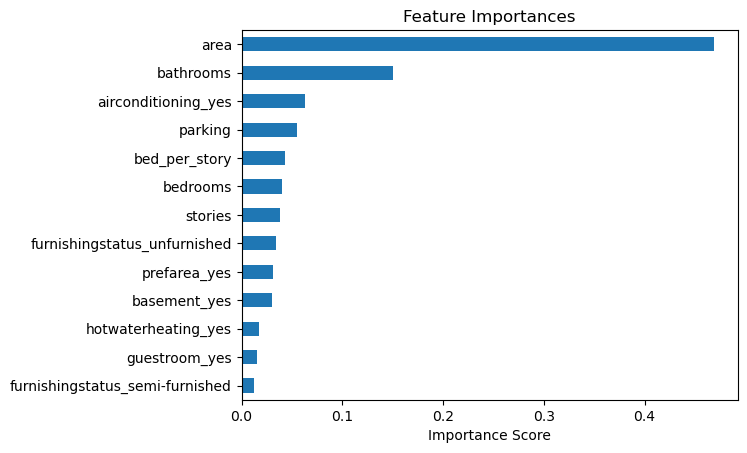

In [386]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.show()

# INSIGHTS AND SUMMARY

### The features that affect price the most: 
"""ANSWER => area and bathrooms features"""

### How accurate was the model: 
"""ANSWER =>  The linear regression model was more accurate than the random forest regresor 
with 65% and 61% accuracy respectively"""

### What surprised you in the data?:
"""ANSWER => bathrooms and bedrooms barely vary yet prices swing massively as area mostly caused price swings"""

### recommendation for a real estate business based on your findings
""" ANSWER => Prioritize area over amenities.
Since area drives price the most, invest in larger properties rather than adding extras like
guestrooms or hot water heating as this highlights how bigger space sells for more every time. """
